# Task 4: Classification Models, Evaluation Metrics & Handling Imbalanced Data


### Step 1: Import Required Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

### Step 2: Load Dataset

In [50]:
# Load the Breast Cancer dataset as recommended
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Target classes: 0 - Malignant, 1 - Benign
print(X.head())
print("\nClass distribution:\n", pd.Series(y).value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

### Step 3: Train-Test Split

In [51]:
# Stratification ensures the train and test sets have the same proportion of class labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Step 4: Feature Scaling

In [52]:
# Initialize and apply StandardScaler
scaler = StandardScaler()

# Fit on training data, then transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 5 & 6: Train Baseline Model & Evaluate

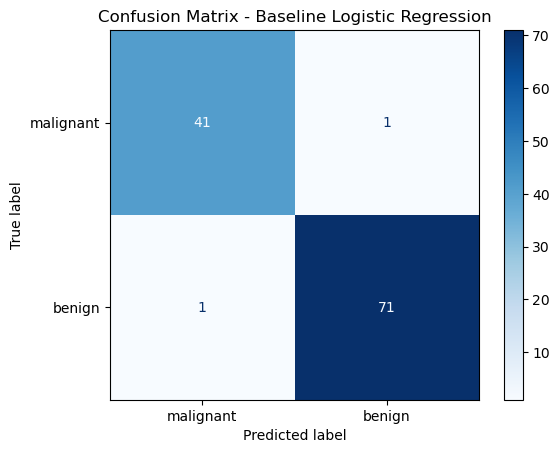

Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [53]:
# Train Baseline Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

### Step 7: Metrics Interpretation
* **True Positives (TP):** The model correctly predicted Malignant (or Benign).
* **False Positives (FP):** The model predicted Benign, but it was actually Malignant.
* **False Negatives (FN):** The model predicted Malignant, but it was actually Benign.
* **Why Accuracy is Insufficient:** If a dataset is heavily skewed, a model that simply guesses the majority class every time will appear highly accurate, but will completely fail to catch the minority cases (which is often the actual goal, like finding tumors).
* **Recall vs Precision:** In medical diagnosis, Recall is more important. We want to minimize False Negatives (telling a patient they are healthy when they actually have cancer).
* **F1-Score:** Preferred for imbalanced data because it mathematically balances Precision and Recall.

### Step 8: ROC Curve & AUC Score

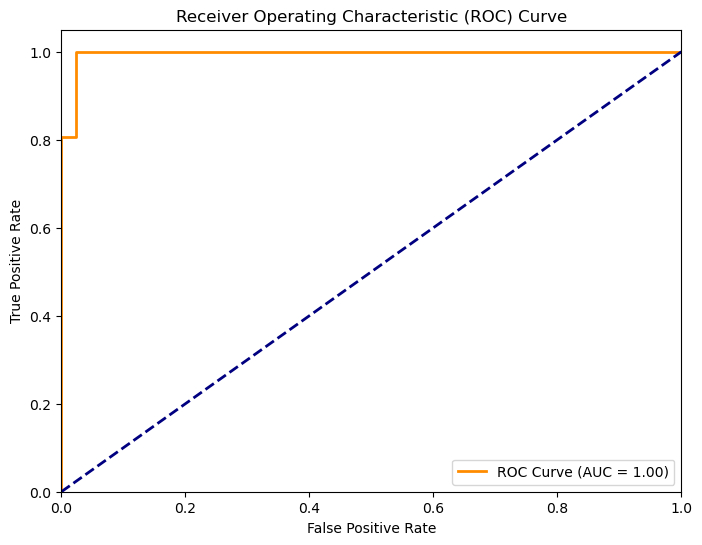

In [54]:
# Get probability predictions for the positive class (class 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate Area Under the Curve (AUC)
auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

### Step 9: Handle Class Imbalance

In [55]:
# Train Logistic Regression with Class Weights
model_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)
model_balanced.fit(X_train_scaled, y_train)

# Evaluate balanced model
y_pred_balanced = model_balanced.predict(X_test_scaled)
print("Classification Report (Balanced Logistic Regression):\n")
print(classification_report(y_test, y_pred_balanced, target_names=data.target_names))

Classification Report (Balanced Logistic Regression):

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



### Step 10: Compare with Decision Tree Classifier

In [56]:
# Train a Decision Tree Classifier
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Evaluate Decision Tree
y_pred_tree = tree.predict(X_test)
print("Classification Report (Decision Tree Classifier):\n")
print(classification_report(y_test, y_pred_tree, target_names=data.target_names))

Classification Report (Decision Tree Classifier):

              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



### Final Model Comparison
* **Logistic Regression:** Highly stable, less prone to extreme overfitting, and highly interpretable. It provides probabilities (which are useful for ROC curves) and performs exceptionally well on this dataset when scaled.
* **Decision Tree:** Can capture non-linear relationships without feature scaling, but is much more prone to overfitting the training data compared to Logistic Regression.
* **Final Selection:** Logistic Regression is the superior choice for this problem due to its high interpretability and strong performance metrics across Recall and Precision.